In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

In [2]:
df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [3]:
df.shape

(918, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.5+ KB


In [5]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,918.000000,918.000000,918.000000,918.000000,918.00000,918.000000
mean,53.510893,132.141612,199.862745,137.689542,0.85512,0.995643
std,9.432617,17.924706,109.154522,25.153455,1.05845,1.142985
min,28.000000,80.000000,0.000000,60.000000,-2.60000,0.000000
25%,47.000000,120.000000,177.250000,120.000000,0.00000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.50000,1.000000
75%,60.000000,140.000000,267.000000,155.750000,1.50000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.20000,4.000000


In [6]:
df.describe(include="object")

,sex,cp,restecg
count,918,918,918
unique,2,3,3
top,Male,asymptomatic,normal
freq,725,496,552


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")

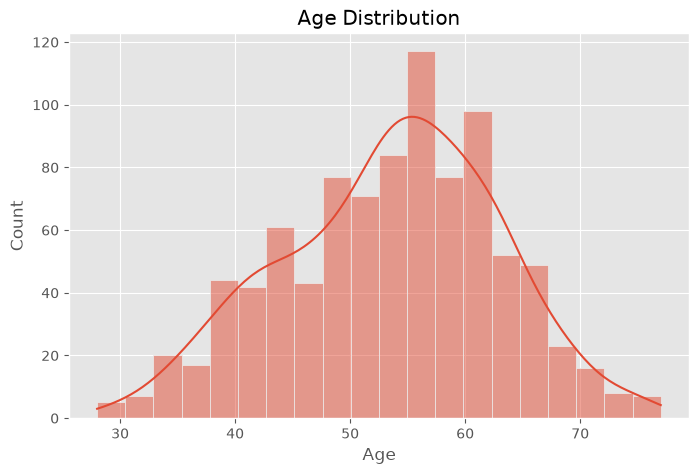

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

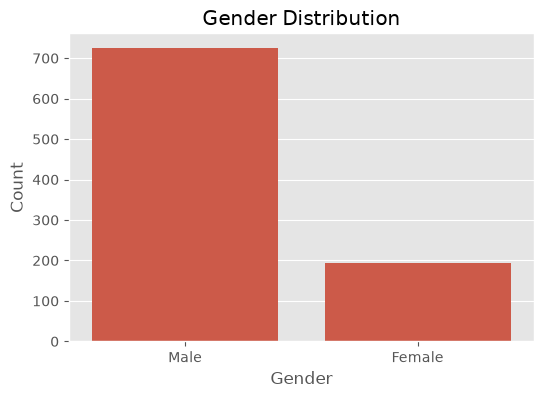

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

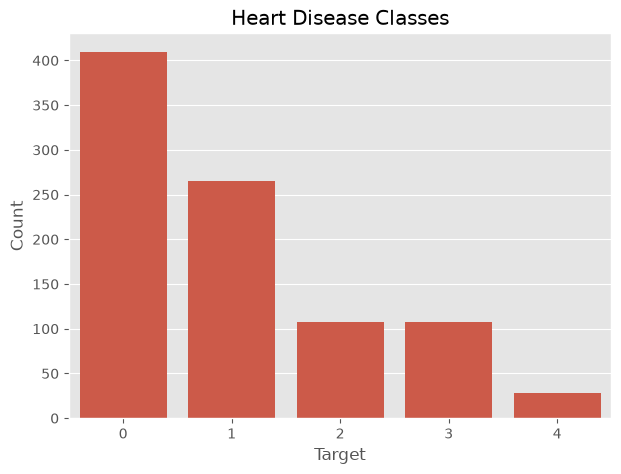

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x="num", data=df)

plt.title("Heart Disease Classes")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [11]:
df_encoded = df.copy()

df_encoded["sex"] = df_encoded["sex"].map({"Male":1, "Female":0})

df_encoded["fbs"] = df_encoded["fbs"].astype(int)
df_encoded["exang"] = df_encoded["exang"].astype(int)

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["cp","restecg"],
    drop_first=True
)

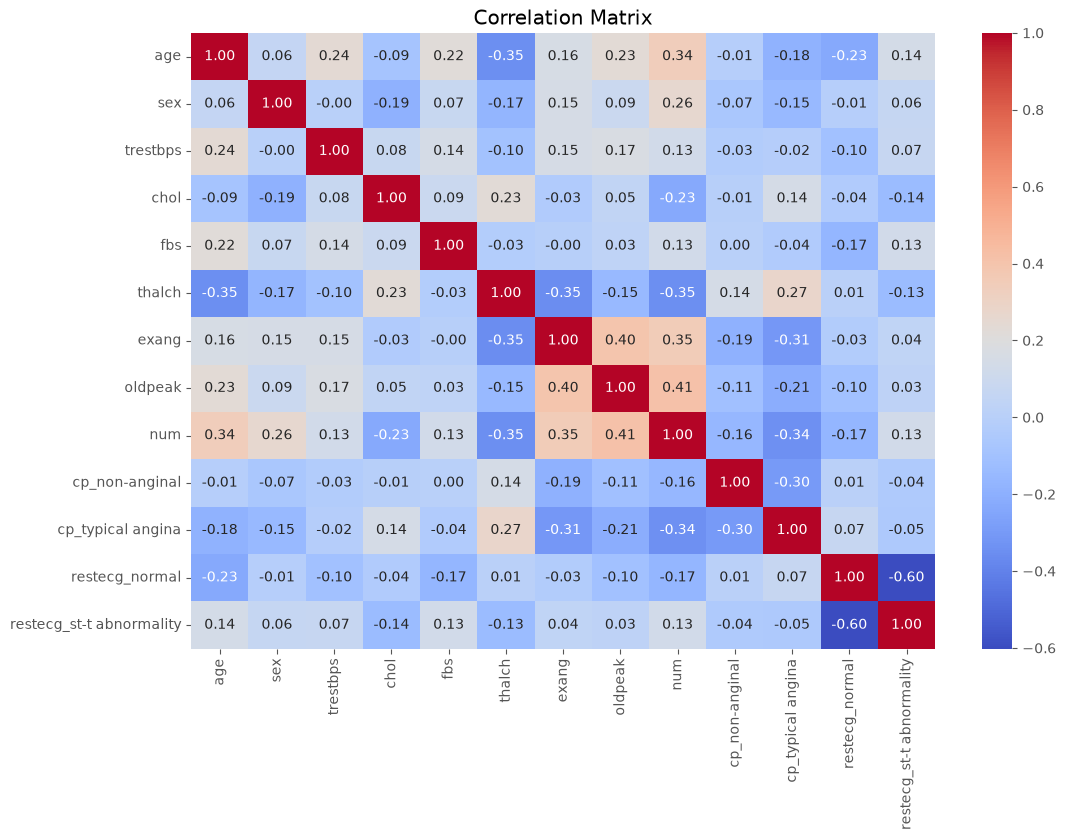

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
X = df.drop("num", axis=1)
y = df["num"]

print(X.shape)
print(y.shape)

(918, 10)
(918,)


In [14]:
X = pd.get_dummies(
    X,
    columns=["sex", "cp", "restecg"],
    drop_first=True
)

X.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,145.0,233.0,True,150.0,False,2.3,True,False,True,False,False
1,67,160.0,286.0,False,108.0,True,1.5,True,False,False,False,False
2,67,120.0,229.0,False,129.0,True,2.6,True,False,False,False,False
3,37,130.0,250.0,False,187.0,False,3.5,True,True,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,False,False,True,False,False


In [15]:
print(df_encoded.columns.tolist())

['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'num', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (734, 12)
X_test : (184, 12)
y_train: (734,)
y_test : (184,)


In [18]:
numerical_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [19]:
X_train.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
636,-0.032164,-0.653510,-1.766312,False,-1.705680,False,-0.807493,True,False,True,True,False
352,-1.308301,-0.653510,0.890155,False,1.268589,False,-0.807493,True,False,True,True,False
136,1.775697,0.726933,-0.199447,False,-0.515972,True,1.640901,True,False,False,True,False
40,1.243973,1.003021,0.259807,False,-0.952198,False,0.134197,False,False,False,False,False
529,-1.520991,-1.205687,0.755081,False,0.475451,False,-0.807493,True,False,False,True,False


In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = log_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5652173913043478


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
dt_pred = dt_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.4945652173913043


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [27]:
rf_pred = rf_model.predict(X_test)

In [28]:
print(X_train.columns.tolist())

['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'sex_Male', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']


In [29]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6032608695652174


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        82
           1       0.47      0.57      0.51        53
           2       0.31      0.18      0.23        22
           3       0.33      0.29      0.31        21
           4       1.00      0.17      0.29         6

    accuracy                           0.60       184
   macro avg       0.58      0.41      0.43       184
weighted avg       0.60      0.60      0.59       184



In [31]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[70 11  1  0  0]
 [12 30  5  6  0]
 [ 5  8  4  5  0]
 [ 1 12  2  6  0]
 [ 0  3  1  1  1]]


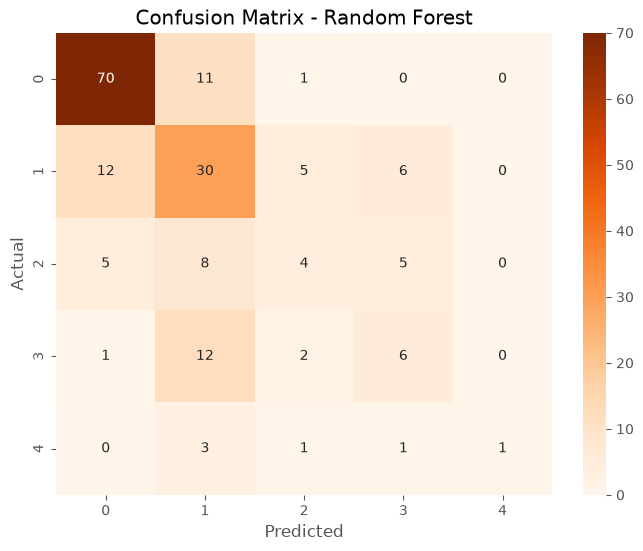

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
knn_pred = knn_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.5597826086956522


In [36]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [37]:
svm_pred = svm_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5869565217391305


In [39]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Random Forest,0.603261
4,SVM,0.586957
0,Logistic Regression,0.565217
3,KNN,0.559783
1,Decision Tree,0.494565


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
    "SVM": svm_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

comparison = pd.DataFrame(results)

comparison.sort_values("Accuracy", ascending=False)

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.603261,0.596958,0.603261,0.586485
4,SVM,0.586957,0.513620,0.586957,0.538303
0,Logistic Regression,0.565217,0.533361,0.565217,0.539922
3,KNN,0.559783,0.495550,0.559783,0.525153
1,Decision Tree,0.494565,0.504216,0.494565,0.497393


In [41]:
import joblib

joblib.dump(rf_model, "../models/random_forest.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [42]:
import os

os.listdir("../models")

['random_forest.pkl', 'scaler.pkl']

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        82
           1       0.41      0.49      0.44        53
           2       0.19      0.18      0.19        22
           3       0.24      0.24      0.24        21
           4       0.00      0.00      0.00         6

    accuracy                           0.49       184
   macro avg       0.32      0.32      0.32       184
weighted avg       0.50      0.49      0.50       184



In [44]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[56 20  3  3  0]
 [12 26  9  5  1]
 [ 4  8  4  5  1]
 [ 2  8  4  5  2]
 [ 0  2  1  3  0]]


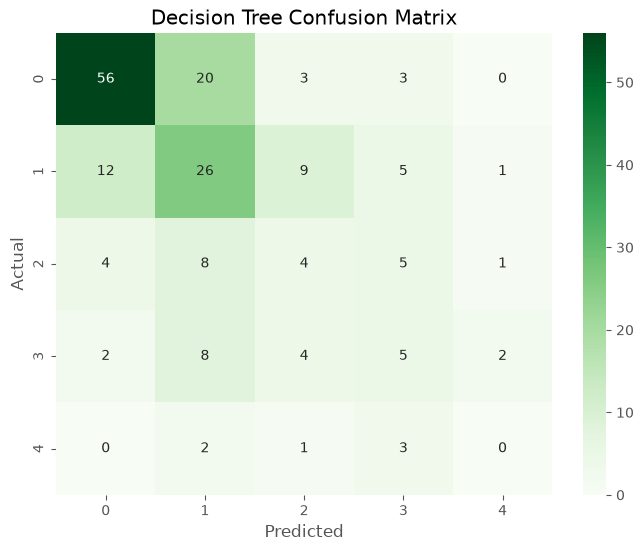

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[74  8  0  0  0]
 [18 30  1  4  0]
 [ 6  8  4  4  0]
 [ 4 15  2  0  0]
 [ 0  2  2  2  0]]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.90      0.80        82
           1       0.48      0.57      0.52        53
           2       0.44      0.18      0.26        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.33      0.33      0.32       184
weighted avg       0.51      0.59      0.54       184



C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

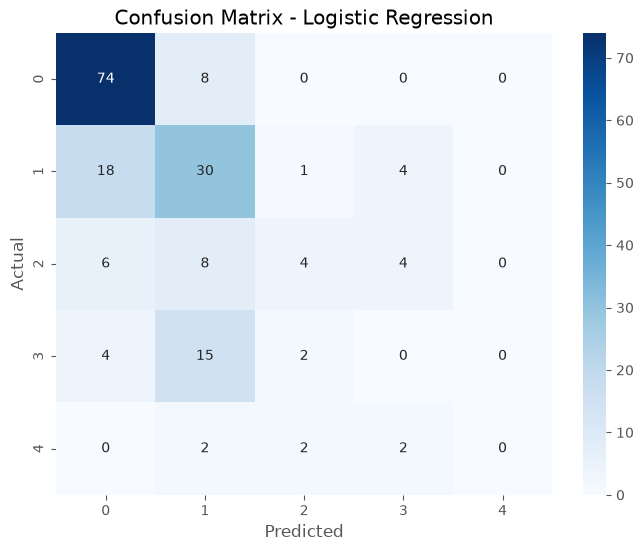

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [49]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df["num"].value_counts()

num
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64

In [52]:
df["num"].value_counts(normalize=True) * 100

num
0    44.662309
1    28.867102
2    11.764706
3    11.655773
4     3.050109
Name: proportion, dtype: float64